# Лабораторная работа: Рекомендательные системы

## Теоретическая часть

### 1. Суть задачи рекомендательных систем
Рекомендательные системы – это алгоритмы, которые анализируют поведение пользователей и предлагают персонализированные рекомендации товаров, фильмов, музыки и других объектов. Основная цель – предсказать предпочтения пользователей на основе имеющихся данных о взаимодействиях.


### 2. Метод коллаборативной фильтрации
Коллаборативная фильтрация (Collaborative Filtering, CF) – это метод рекомендаций, основанный на анализе поведения пользователей. Он работает на основе предположения, что пользователи с похожими предпочтениями в прошлом будут делать схожий выбор в будущем.

Существует два основных подхода:
1. **User-based CF** – рекомендации строятся на основе сходства пользователей.
2. **Item-based CF** – рекомендации строятся на основе сходства объектов.

### 3. Латентные факторные модели (Matrix Factorization)
Коллаборативная фильтрация может быть реализована через матричное разложение. Пусть у нас есть матрица взаимодействий пользователей и объектов R, где $( R_{u,i} )$ – оценка пользователя ( u ) для объекта ( i ). Тогда разложение можно представить в виде:
$$
R \approx U \cdot V^T
$$
где:
- ( U ) – матрица эмбеддингов пользователей,
- ( V ) – матрица эмбеддингов объектов.

Предсказание рейтинга рассчитывается как:
$$
\hat{R}_{u,i} = U_u \cdot V_i^T
$$

В данной лабораторной работе предполагается использование **нейросетевого метода**, который обучает эмбеддинги пользователей и объектов с помощью полносвязных слоев. Входные данные – индексы пользователей и объектов, которые преобразуются в векторные представления, а затем подаются на вход нейросети.


## Практическая часть
В данной работе вам предлагается реализовать рекомендательную систему на основе метода коллаборативной фильтрации, используя нейросетевую модель. Вы должны:
1. Подготовить данные: загрузить свой датасет (например, рейтинг фильмов, товаров, книг и т. д.).
2. Разбить данные на тренировочный и тестовый наборы.
3. Обучить модель, используя эмбеддинги пользователей и объектов.
4. Оценить качество модели на тестовом наборе.
5. Вывести список рекомендаций для выбранного пользователя.

In [1]:
# Импорты
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Определяем устройство (используем GPU, если доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ torch импортирован")
print(device)
print("Версия:", torch.__version__)
print("GPU доступен:", torch.cuda.is_available())
print("Тип device:", type(torch.device('cpu')))


✅ torch импортирован
cpu
Версия: 2.9.1+cpu
GPU доступен: False
Тип device: <class 'torch.device'>


In [2]:
# Определяем названия столбцов
columns = ['reviewerID', 'asin', 'overall']
df = pd.read_csv('data.csv', usecols=columns)

df['user_id'] = pd.factorize(df['reviewerID'])[0]
df['music_id'] = pd.factorize(df['asin'])[0]

df = df.drop(['reviewerID'], axis=1)
df = df.drop(['asin'], axis=1)

df

,overall,user_id,music_id
0,5.0,0,0
1,5.0,1,0
2,5.0,2,0
3,5.0,3,0
4,5.0,4,0
...,...,...,...
10256,5.0,1249,899
10257,5.0,711,899
10258,4.0,1294,899
10259,4.0,1160,899


In [3]:
# Определяем датасет PyTorch
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].values, dtype=torch.long)
        self.items = torch.tensor(df['music_id'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['overall'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

In [ ]:
# Определяем нейросетевую модель для коллаборативной фильтрации
class RecommenderNN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super(RecommenderNN, self).__init__()
        # Эмбеддинги пользователей и фильмов
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        # Полносвязные слои для предсказания рейтинга
        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, user, item):
        # Получаем эмбеддинги пользователя и фильма
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)

        # Объединяем эмбеддинги
        x = torch.cat([user_emb, item_emb], dim=1)

        # Пропускаем через полносвязные слои
        return self.fc_layers(x).squeeze()

In [5]:
# Определяем количество пользователей и фильмов
num_users = df['user_id'].nunique()
num_items = df['music_id'].nunique()


In [6]:
# Создаём датасеты и загрузчики данных
dataset = RatingsDataset(df)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

In [7]:
# Инициализация модели
model = RecommenderNN(num_users, num_items).to(device)

# Определяем функцию потерь (MSE) и оптимизатор (Adam)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [8]:
train_losses = []
train_rmse = []
train_mae = []
train_roc_auc = []
train_precision = []
train_recall = []
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score, precision_score, recall_score


for epoch in range(100):
    # losses.append(0)
    model.train()
    total_loss = 0
    all_predictions = []
    all_ratings = []
    for users, items, ratings in train_loader:
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)
        optimizer.zero_grad()
        predictions = model(users, items)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        all_predictions.extend(predictions.cpu().detach().numpy())
        all_ratings.extend(ratings.cpu().detach().numpy())
        
        
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Regression metrics
    rmse = math.sqrt(mean_squared_error(all_ratings, all_predictions))
    mae = mean_absolute_error(all_ratings, all_predictions)
    train_rmse.append(rmse)
    train_mae.append(mae)

    # Classification metrics (binary: rating >= 4 → 1)
    y_true = (np.array(all_ratings) >= 4).astype(int)
    y_scores = np.array(all_predictions)
    y_pred = (y_scores >= 4).astype(int)

    try:
        roc_auc = roc_auc_score(y_true, y_scores)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
    except ValueError:
        roc_auc = np.nan
        precision = np.nan
        recall = np.nan

    train_roc_auc.append(roc_auc)
    train_precision.append(precision)
    train_recall.append(recall)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, "
          f"ROC-AUC={roc_auc:.4f}, Precision={precision:.4f}, Recall={recall:.4f}")
    print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}')

# Оценка модели на тестовом наборе
model.eval()
test_predictions = []
test_ratings = []
with torch.no_grad():
    for users, items, ratings in test_loader:
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)
        predictions = model(users, items)
        test_predictions.extend(predictions.cpu().numpy())
        test_ratings.extend(ratings.cpu().numpy())

# Средняя ошибка на тестовом наборе
test_rmse = math.sqrt(mean_squared_error(test_ratings, test_predictions))
test_mae = mean_absolute_error(test_ratings, test_predictions)

print(f'\nTest RMSE: {test_rmse:.4f}, Test MAE: {test_mae:.4f}')

# Рекомендации для нескольких случайных пользователей
random_users = np.random.choice(df['user_id'].unique(), size=5)

print("\nRecommendations for random users:")
for user_id in random_users:
    # Предсказания для всех объектов для выбранного пользователя
    user_tensor = torch.tensor([user_id] * num_items, dtype=torch.long).to(device)
    item_tensor = torch.tensor(range(num_items), dtype=torch.long).to(device)

    with torch.no_grad():
        predictions = model(user_tensor, item_tensor).cpu().numpy()

    # Выбираем топ-5 рекомендованных объектов
    top_items = predictions.argsort()[-5:][::-1]

    print(f"User {user_id + 1}: Recommended items {top_items + 1}")

Epoch 1: Loss=1.5250, RMSE=1.2349, MAE=0.8982, ROC-AUC=0.5113, Precision=0.8834, Recall=0.7383
Epoch 1, Loss: 1.52503052390894
Epoch 2: Loss=0.9038, RMSE=0.9507, MAE=0.7172, ROC-AUC=0.5922, Precision=0.8935, Recall=0.8360
Epoch 2, Loss: 0.9037843420520628
Epoch 3: Loss=0.8036, RMSE=0.8964, MAE=0.6693, ROC-AUC=0.6744, Precision=0.9045, Recall=0.8610
Epoch 3, Loss: 0.803599344708069
Epoch 4: Loss=0.7441, RMSE=0.8626, MAE=0.6451, ROC-AUC=0.7187, Precision=0.9117, Recall=0.8644
Epoch 4, Loss: 0.7441066741856218
Epoch 5: Loss=0.6970, RMSE=0.8349, MAE=0.6173, ROC-AUC=0.7599, Precision=0.9201, Recall=0.8799
Epoch 5, Loss: 0.6970339424301804
Epoch 6: Loss=0.6471, RMSE=0.8044, MAE=0.5961, ROC-AUC=0.7991, Precision=0.9276, Recall=0.8828
Epoch 6, Loss: 0.6470502055455254
Epoch 7: Loss=0.6081, RMSE=0.7798, MAE=0.5808, ROC-AUC=0.8284, Precision=0.9381, Recall=0.8791
Epoch 7, Loss: 0.6081431653699156
Epoch 8: Loss=0.5770, RMSE=0.7596, MAE=0.5663, ROC-AUC=0.8562, Precision=0.9473, Recall=0.8712
Epoch

In [ ]:
from collections import Counter
top_k_recommendations = {}
K=5
with torch.no_grad():
    for user_id in range(num_users):
        user_tensor = torch.full(
            (num_items,),
            user_id,
            dtype=torch.long,
            device=device
        )
        item_tensor = torch.arange(
            num_items,
            dtype=torch.long,
            device=device
        )

        predictions = model(user_tensor, item_tensor).cpu().numpy()
        top_items = predictions.argsort()[-K:][::-1]
        top_k_recommendations[user_id + 1] = top_items + 1 

all_top_items = np.concatenate(list(top_k_recommendations.values()))

item_counts = Counter(all_top_items)

most_popular_items = [item for item, count in item_counts.most_common(5)]

print("САМЫЕ ПОПУЛЯРНЫЕ МУЗЫКИ ТОП-5:", most_popular_items)

САМЫЕ ПОПУЛЯРНЫЕ МУЗЫКИ ТОП-5: [np.int64(484), np.int64(424), np.int64(867), np.int64(543), np.int64(885)]


ID самых популярных музык катируемых среди всех пользователей.

In [ ]:

import matplotlib.pyplot as plt
epochs = range(1, 101)

plt.figure(figsize=(15, 10))
plt.suptitle(f'Метрики обучения модели (batch=8, epoch=10, RMSE={test_rmse}, MAE={test_mae})', fontsize=16, fontweight='bold')


# Loss
plt.subplot(2, 3, 1)
plt.plot(epochs, train_losses, marker='o', color='blue', markersize=2)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# RMSE
plt.subplot(2, 3, 2)
plt.plot(epochs, train_rmse, marker='o', color='red', markersize=2)
plt.title('Training RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.grid(True)

# MAE
plt.subplot(2, 3, 3)
plt.plot(epochs, train_mae, marker='o', color='green', markersize=2)
plt.title('Training MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.grid(True)

# ROC-AUC
plt.subplot(2, 3, 4)
plt.plot(epochs, train_roc_auc, marker='o', color='purple', markersize=2)
plt.title('Training ROC-AUC')
plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.grid(True)

# Precision
plt.subplot(2, 3, 5)
plt.plot(epochs, train_precision, marker='o', color='orange', markersize=2)
plt.title('Training Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.grid(True)

# Recall
plt.subplot(2, 3, 6)
plt.plot(epochs, train_recall, marker='o', color='brown', markersize=2)
plt.title('Training Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.grid(True)

plt.tight_layout()
plt.show()

# **ТЕСТЫ**

### ТЕСТ 1
- **Batch: 64**
- **Epoch: 10**
- **Learning Rate: 0.005**

Базовый тест, с ним будем сравнивать остальные результаты.
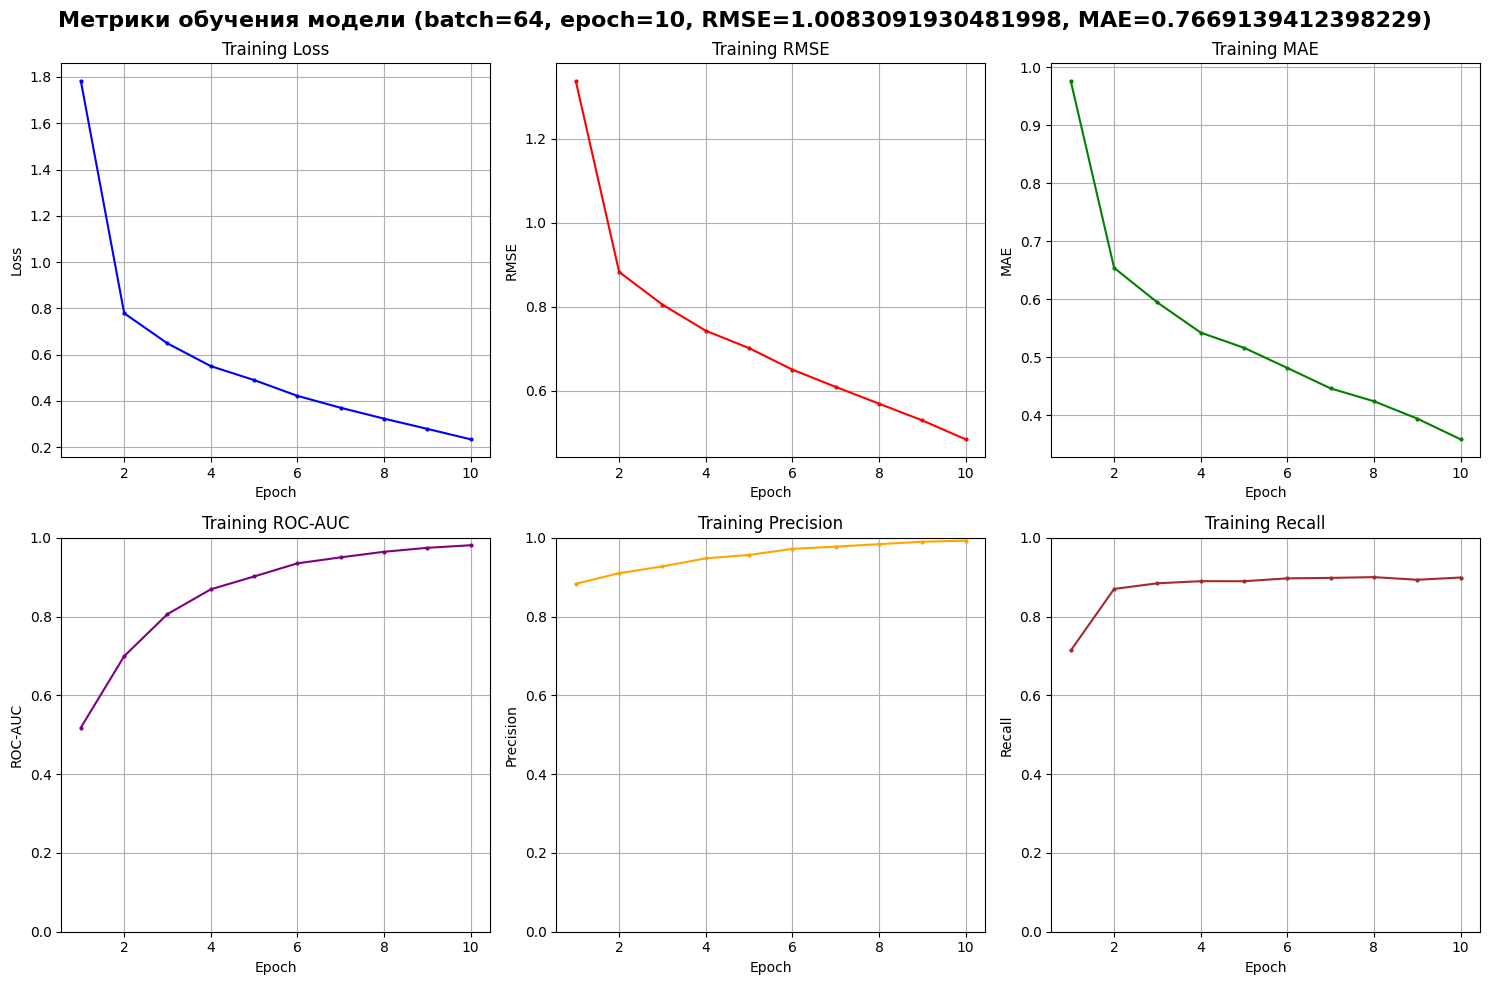

### ТЕСТ 2
- **Batch: 64**
- **Epoch: 10**
- **Learning Rate: 0.005**
- **СЛОИ DROPOUT**

Добавили слои DROPOUT, чтобы модель постоянно обучалась на разных нейронах. 20% нейронов отбрасываются. По результатам видно, что RMSE улучшилось на 2%, а MAE на 8%. Незначительно, продолжаем тесты
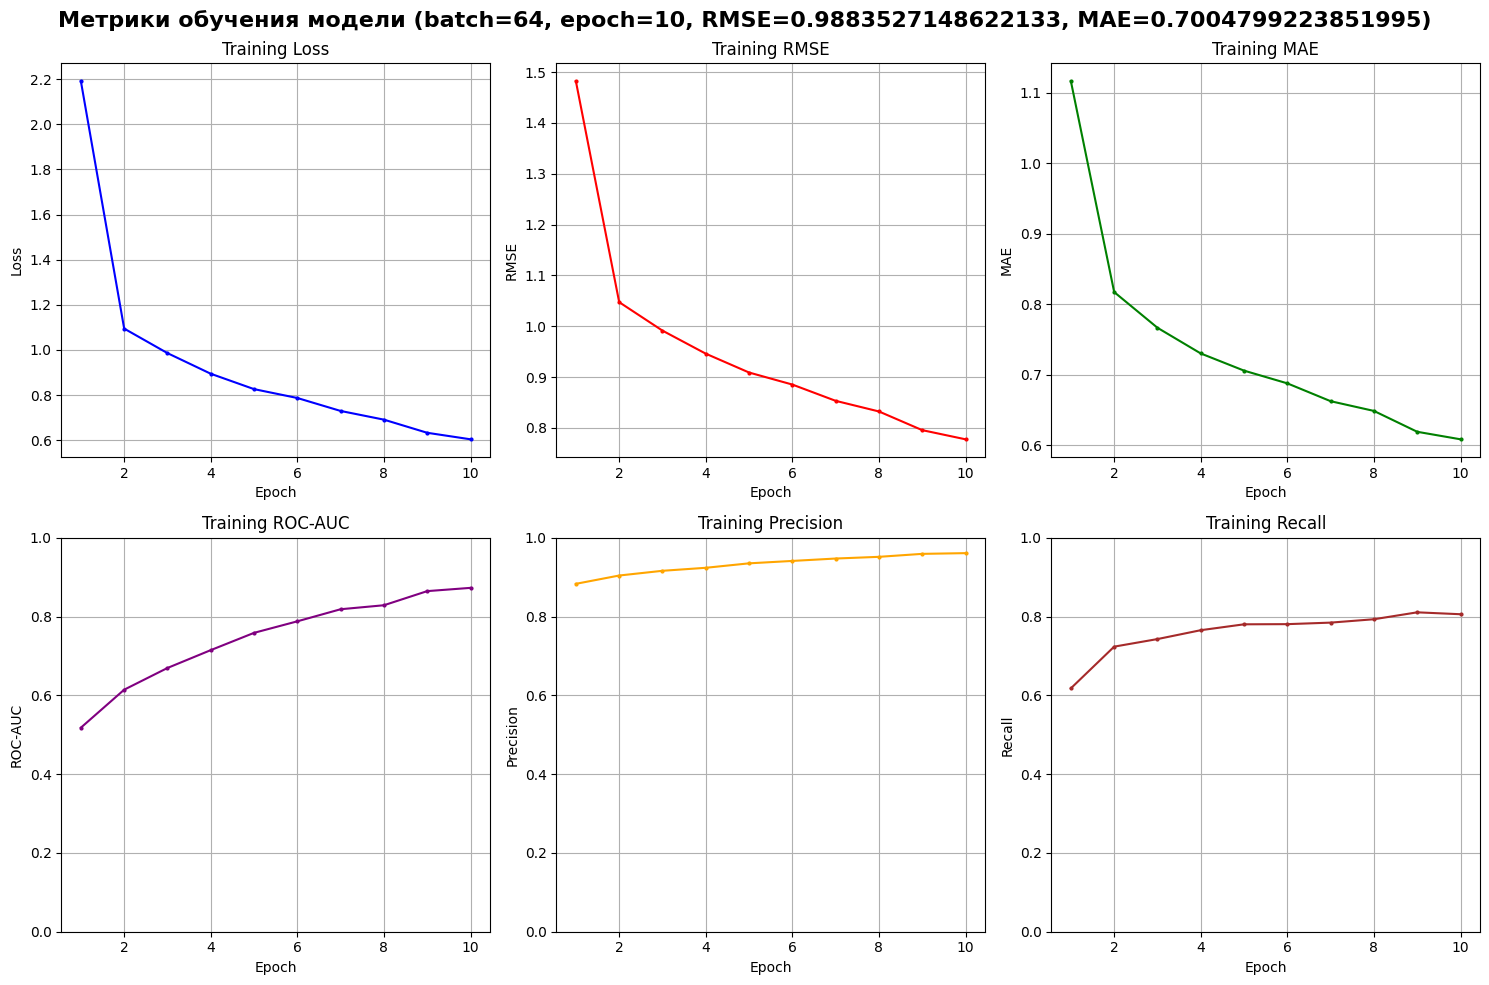

### ТЕСТ 3
- **Batch: 64**
- **Epoch: 100**
- **Learning Rate: 0.005**

Тут без DROPOUT. Попробуем увеличить кол-во эпох. Результаты по сравнении с ТЕСТОМ 1 практически не изменились. Обучение вышло на плато уже на 20 эпохе. Переобучение.
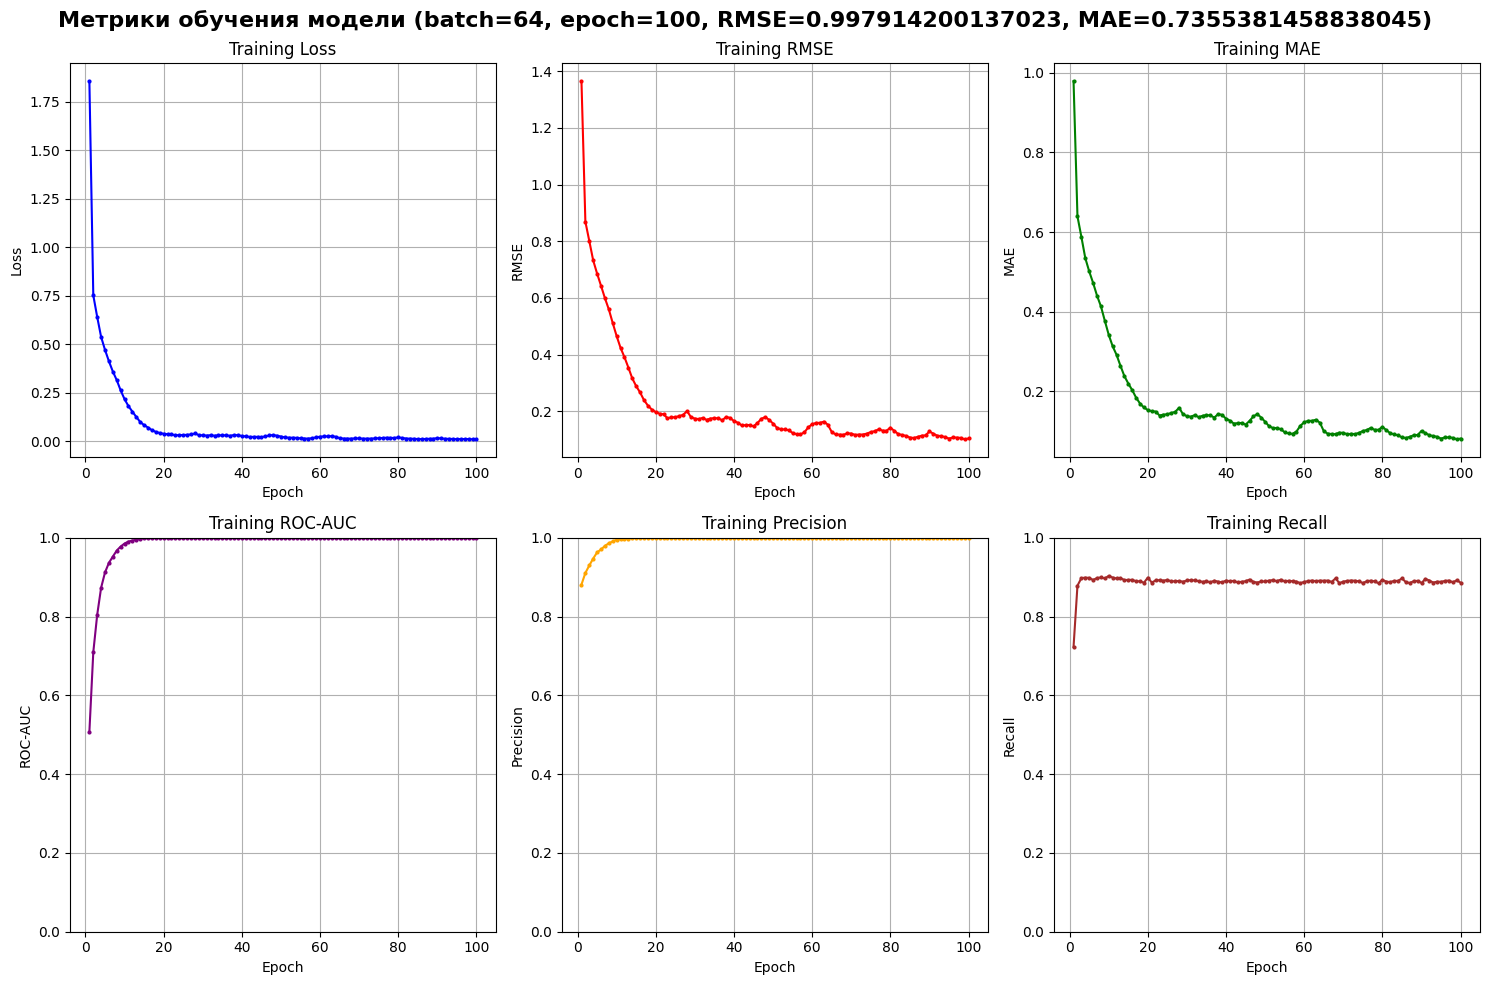

### ТЕСТ 4
- **Batch: 64**
- **Epoch: 100**
- **Learning Rate: 0.005**
- **СЛОИ DROPOUT**

ТЕСТ 3, но добавим DROPOUT. Результат получился лучше, чем за предыдущие тесты. RMSE = 0.94 (ТЕСТ 1 RMSE = 1.08). Теперь плато начинается на 50 эпохе, следовательно, DROPOUT слои имеют практическое значение и уменьшают переобучение.
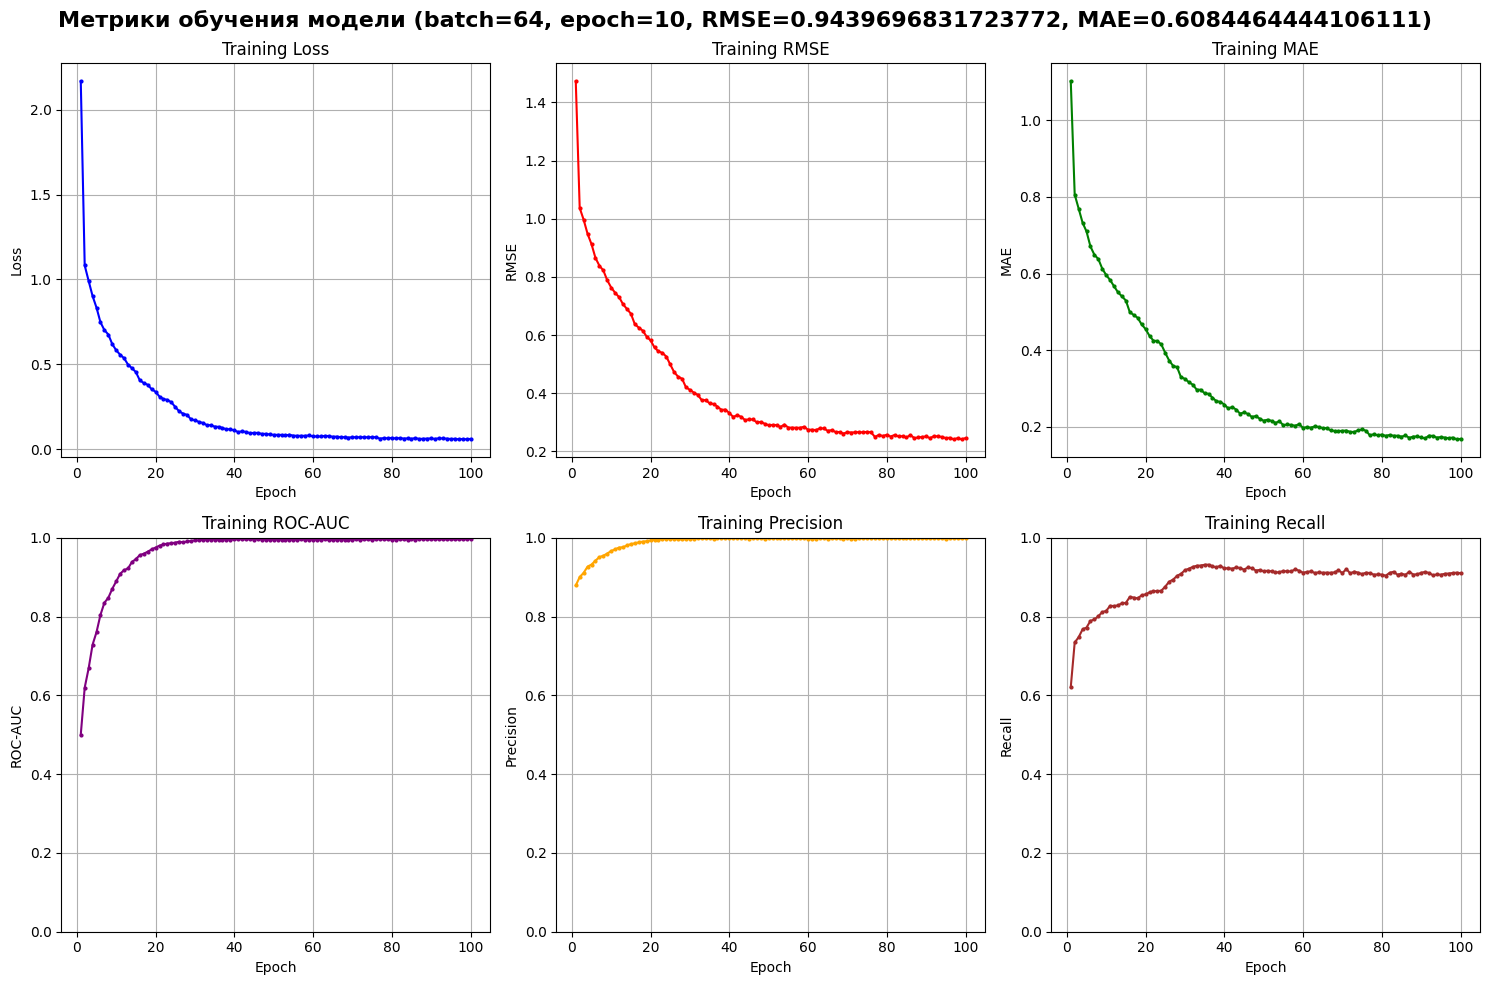

### ТЕСТ 5
- **Batch: 8**
- **Epoch: 10**
- **Learning Rate: 0.005**

Попробуем повторить все тесты, но теперь уменьшим размер BATCH. Сравним с ТЕСТ 1. Видно, что RMSE незначительно меньше, а MAE чуть больше. Продолжаем тесты.
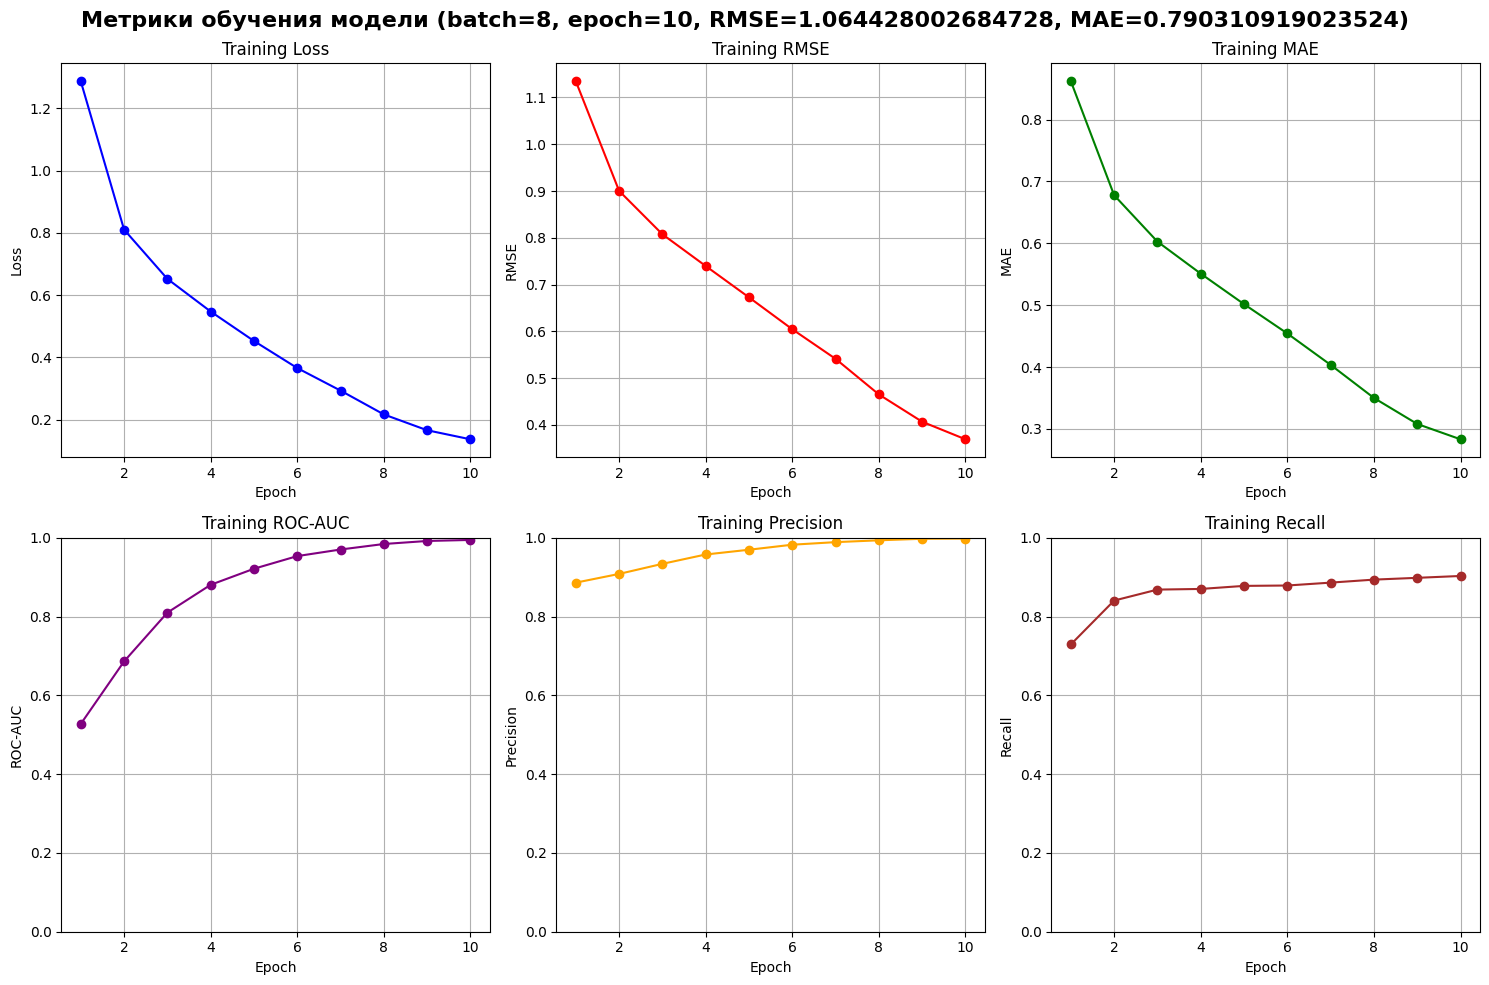

### ТЕСТ 6
- **Batch: 8**
- **Epoch: 10**
- **Learning Rate: 0.005**
- **СЛОИ DROPOUT**

Добавим DROPOUT. Ситуация улучшилась.
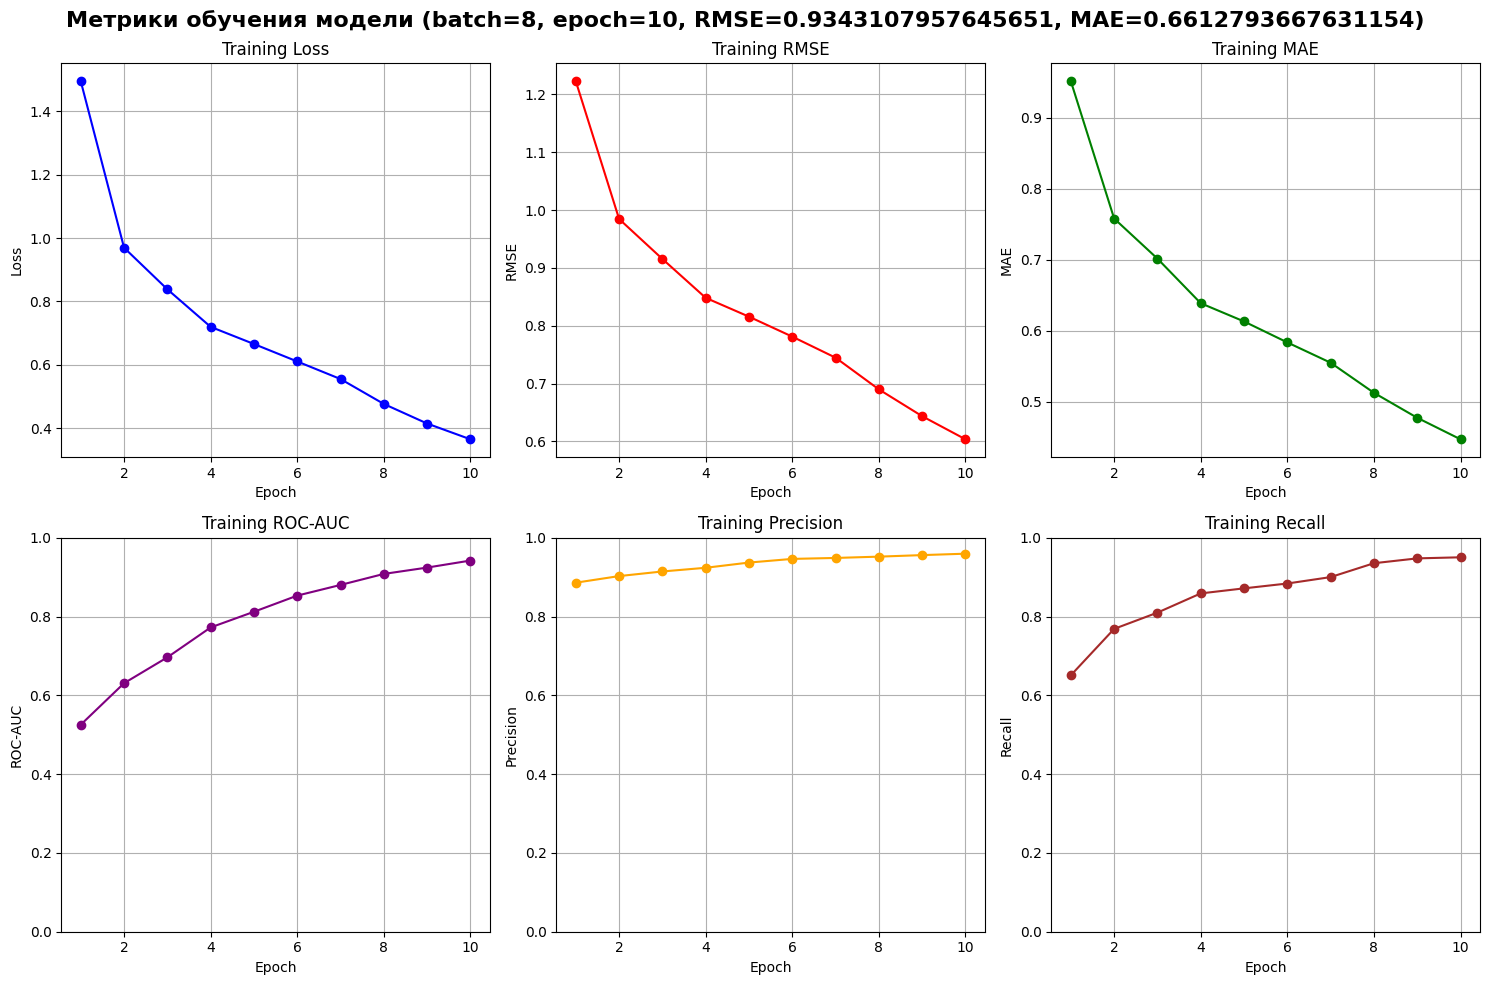


### ТЕСТ 7
- **Batch: 8**
- **Epoch: 100**
- **Learning Rate: 0.005**
- **СЛОИ DROPOUT**

Увеличим кол-во эпох. Результат получился хорошим. Тест показал наименьшее MAE, а RMSE одинаковое что и в тесте 4. При этом видно, что плато наступает около 60 эпохи, но значения сильно скачет и ушла плавность графика.
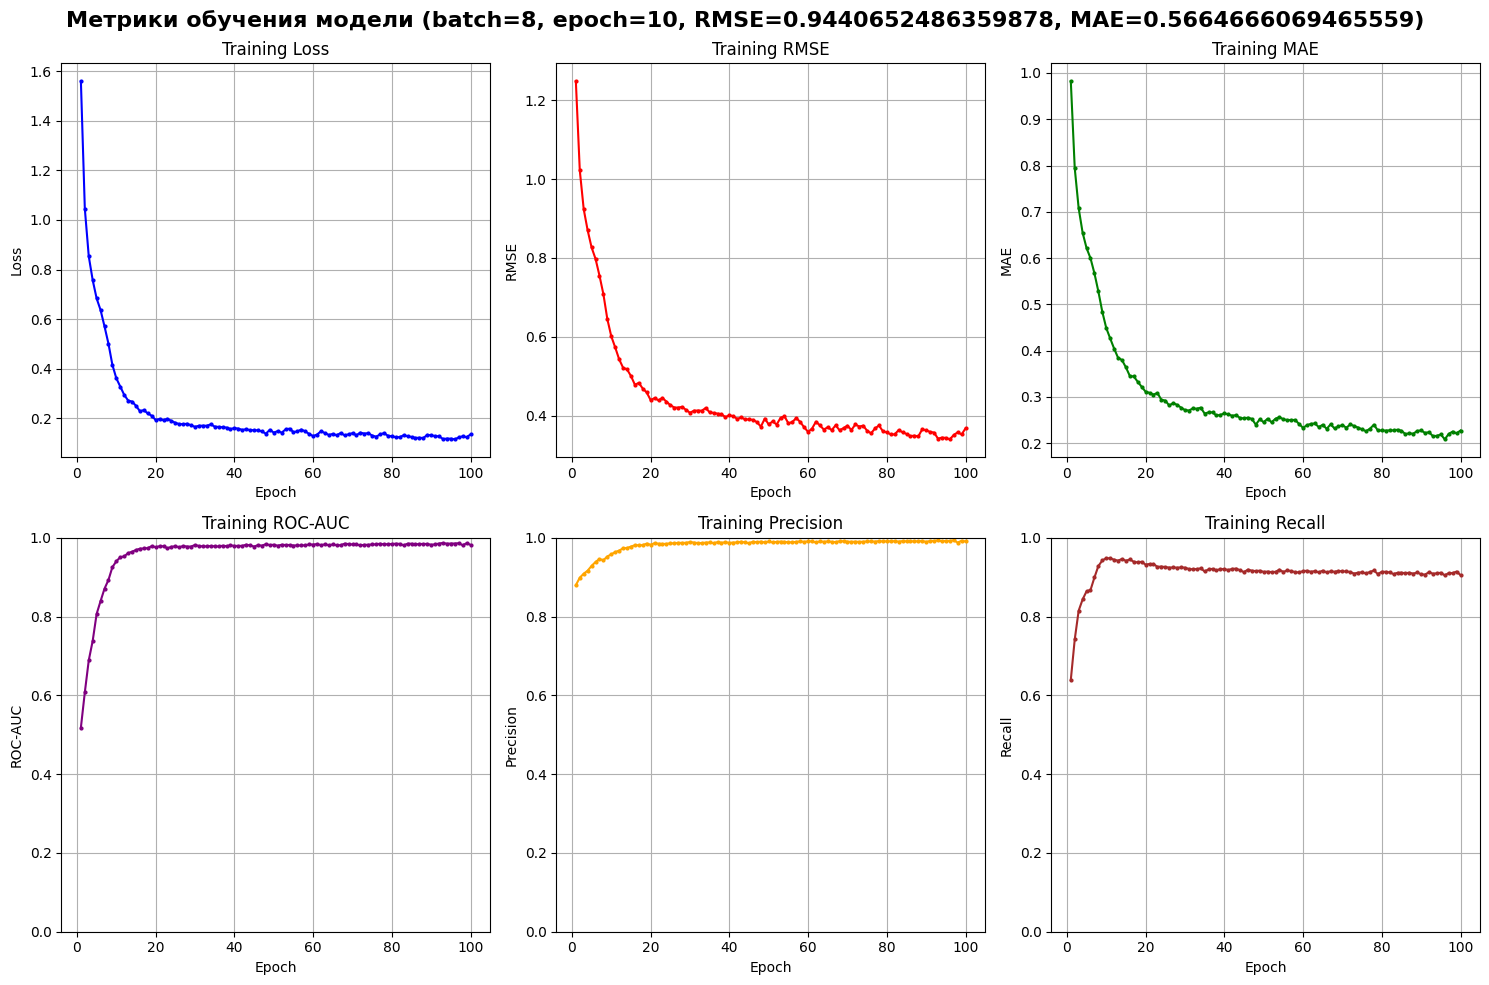

### ТЕСТ 8
- **Batch: 8**
- **Epoch: 100**
- **Learning Rate: 0.001**
- **СЛОИ DROPOUT**

В данном тесте попробуем уменьшить скорость обучения. Наилучший результат RMSE = 0.92. Из-за уменьшения скорости обучения график потерь стал плавнее. Плато наступило около 80 эпохи. Результатом доволен.
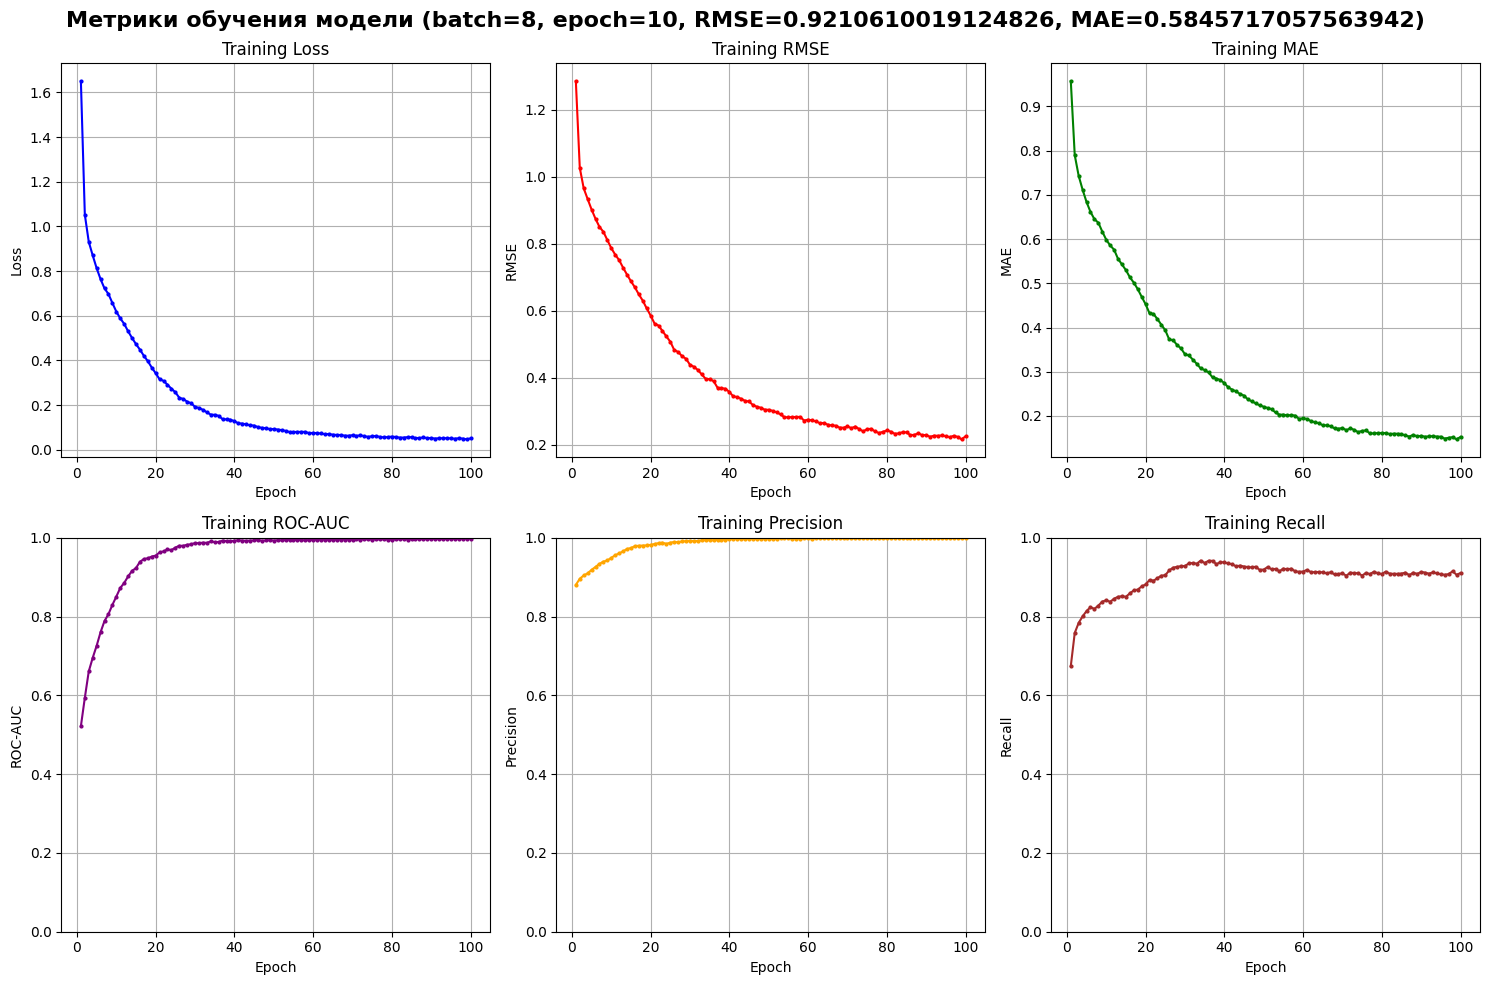

## **ВЫВОДЫ**

- #### Есть такое наблюдение: RECALL прыгал и потом убывал. Значение эпохи, в которой значение RECALL максимально, визуально практически всегда совпадает с точкой перегиба графика потерь (точкой, где скорость убывания графика уменьшается).

#### В ходе работы были проведены эксперименты, направленные на улучшение нейросетевой модели рекомендательной системы, включающие подбор гиперпараметров и добавление методов регуляризации. По сравнению с базовой конфигурацией, усовершенствованная модель показала более высокие результаты на тестовой выборке: значение RMSE снизилось с 1.08 до 0.92, а MAE — с 0.76 до 0.58. Полученные результаты указывают на повышение точности предсказаний и улучшение обобщающей способности модели.

#### Использование регуляризации позволило снизить эффект переобучения, а увеличение кол-ва эпох более подробно раскрывал эффективность обучения конкретными параметрами, без DROPOUT и уменьшения LEARNING RATE при большом кол-ве эпох наступало плато на графике потерь (переобучение). В совокупности это привело к формированию более качественных персонализированных рекомендаций для пользователей.